# Credit Risk Data Exploration

This notebook explores the anonymized credit history dataset from the Alfa-Bank credit scoring competition hosted on ODS.ai.

The goal of the competition is to predict the probability of client default based on historical credit bureau data.

In this notebook, we focus on:

- dataset structure;
- number of credit records per client;
- encoded numerical features;
- payment history features;
- categorical credit attributes;
- observations that will later guide feature engineering.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "train_data"
TARGET_PATH = PROJECT_ROOT / "data" / "train_target.csv"

## 1. Dataset overview

The raw dataset contains credit history records. A single client can have multiple rows, with each row representing one credit record.

For exploratory analysis, we first load one partition of the training dataset.

In [3]:
sample_path = DATA_DIR / "train_data_0.pq"

df = pd.read_parquet(sample_path)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"Unique clients: {df['id'].nunique():,}")

Rows: 1,974,724
Columns: 61
Unique clients: 250,000


## 2. Credit History per Client

Each client can have multiple credit records. Understanding the distribution of credit records per client is important because the raw data is structured at the credit level, while the prediction target is defined at the client level.

In [4]:
credits_per_client = df.groupby('id').size()
credits_per_client.describe()

count    250000.000000
mean          7.898896
std           5.743369
min           1.000000
25%           3.000000
50%           7.000000
75%          11.000000
max          51.000000
dtype: float64

In [5]:
print(f"Average number of credits per client: {credits_per_client.mean():.2f}")
print(f"Median number of credits per client: {credits_per_client.median():.0f}")
print(f"Minimum: {credits_per_client.min()}")
print(f"Maximum: {credits_per_client.max()}")

Average number of credits per client: 7.90
Median number of credits per client: 7
Minimum: 1
Maximum: 51


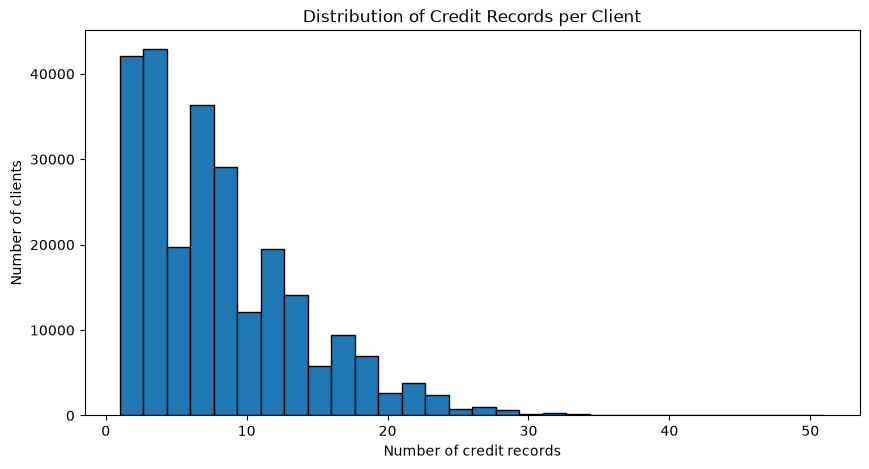

In [6]:
# Visualize the number of credit records between clients
plt.figure(figsize=(10, 5))
plt.hist(credits_per_client,
         bins=30,
         edgecolor='black')
plt.xlabel("Number of credit records")
plt.ylabel("Number of clients")
plt.title("Distribution of Credit Records per Client")
plt.show()

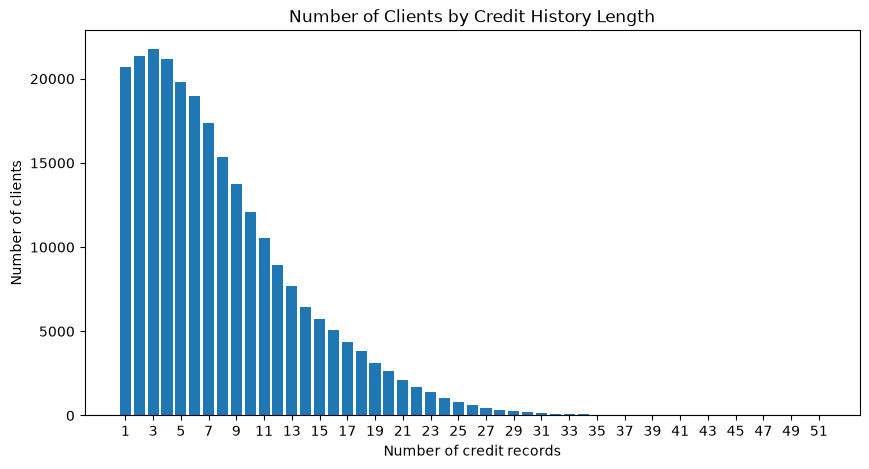

In [7]:
credit_counts = credits_per_client.value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(credit_counts.index,
        credit_counts.values)
plt.xlabel("Number of credit records")
plt.ylabel("Number of clients")
plt.title("Number of Clients by Credit History Length")
plt.xticks(range(1, credits_per_client.max() + 1, 2))
plt.show()

### Key observation

The typical client has several credit records in their history, with a median of 7 records. However, the number of records varies considerably, with some clients having substantially longer credit histories.

This confirms that the raw data contains multiple records per client and will require aggregation to the client level before model training.

## 3. Target Distribution

The target variable 'flag' indicates whether a client defaulted.

Before building a classification model, it is important to understand the class distribution and check whether the target is balanced.

In [8]:
target = pd.read_csv(TARGET_PATH)

print(f"Rows {target.shape[0]:,}")
print(f"Columns: {target.shape[1]}")
target.head()

Rows 3,000,000
Columns: 2


,id,flag
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0


In [9]:
target['flag'].value_counts()

flag
0    2893558
1     106442
Name: count, dtype: int64

In [10]:
target_distribution = target['flag'].value_counts(normalize=True).mul(100)
print(target_distribution)

flag
0    96.451933
1     3.548067
Name: proportion, dtype: float64


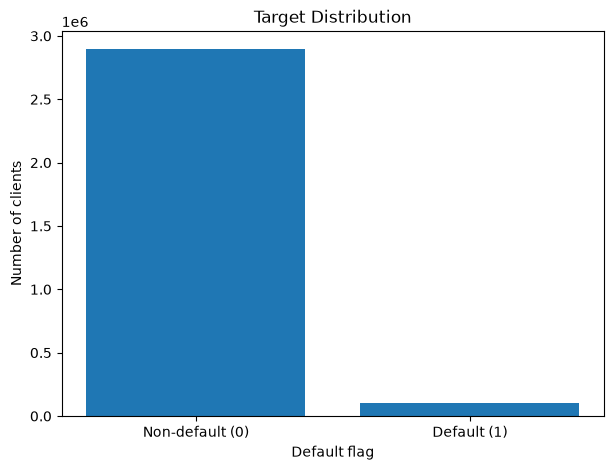

In [11]:
target_counts = target["flag"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

plt.bar(["Non-default (0)", "Default (1)"],
        target_counts.values)

plt.xlabel("Default flag")
plt.ylabel("Number of clients")
plt.title("Target Distribution")

plt.show()

### Key observation

The target variable is highly imbalanced:

- 96.45% of clients belong to the non-default class.
- 3.55% of clients belong to the default class.

Therefore, accuracy would not be an informative primary metric for this problem. ROC-AUC is used to evaluate the models, as it is more suitable for assessing the ranking quality of predictions under class imbalance.

## 4. Missing Values

We next examine missing values in the credit history data.

The proportion of missing values can help identify features that may require special treatment during preprocessing.

In [12]:
missing = (df.isna().sum().to_frame("missing_count"))
missing["missing_pct"] = (missing["missing_count"] / len(df) * 100)
missing = missing.sort_values("missing_pct", ascending=False)
missing.head(20)

,missing_count,missing_pct
id,0,0.0
rn,0,0.0
pre_since_opened,0,0.0
pre_since_confirmed,0,0.0
pre_pterm,0,0.0
pre_fterm,0,0.0
pre_till_pclose,0,0.0
pre_till_fclose,0,0.0
pre_loans_credit_limit,0,0.0
pre_loans_next_pay_summ,0,0.0


### Key observation

No missing values were found in the analyzed dataset partition.

All 61 features are fully populated, so no missing-value imputation is required at this stage.

## 5. Feature Cardinality

The number of unique values in a feature provides useful information about its structure.

Low-cardinality features may represent binary or categorical information, while features with many unique values are more likely to contain continuous or highly variable information.

In [13]:
feature_cardinality = (df.drop(columns=["id", "rn"]).nunique().sort_values())
feature_cardinality

pre_loans_total_overdue           1
is_zero_over2limit                2
is_zero_maxover2limit             2
is_zero_loans90                   2
is_zero_loans6090                 2
is_zero_loans3060                 2
is_zero_loans530                  2
is_zero_loans5                    2
is_zero_util                      2
pclose_flag                       2
fclose_flag                       2
pre_loans_max_overdue_sum         3
pre_loans6090                     3
pre_loans90                       4
enc_paym_0                        4
enc_paym_3                        4
enc_paym_11                       4
enc_paym_10                       4
enc_paym_17                       4
enc_paym_16                       4
enc_paym_15                       4
enc_paym_14                       4
enc_paym_13                       4
enc_paym_12                       4
enc_paym_7                        4
enc_paym_6                        4
enc_paym_9                        4
enc_paym_8                  

In [14]:
feature_cardinality.describe()

count    59.000000
mean      6.694915
std       5.940087
min       1.000000
25%       4.000000
50%       4.000000
75%       7.000000
max      20.000000
dtype: float64

### Key observations

The feature set contains a large number of low-cardinality variables.

Several groups of features have a particularly clear structure:

- binary variables with 2 unique values;
- encoded payment history features with 4 unique values;
- categorical credit attributes with 4–7 unique values;
- discretized `pre_*` features with up to 20 unique values.

The payment history features (`enc_paym_*`) are especially notable: all 24 periods contain four distinct values. This structure will be taken into account during feature engineering.

## 6. Credit Record Ordering

The `rn` feature contains 51 unique values. We examine its relationship with the number of credit records per client to understand whether it represents the position of a credit record within a client's history.

In [15]:
rn_stats = df.groupby("id")["rn"].agg(min_rn="min",
                                      max_rn="max",
                                      unique_rn="nunique",
                                      records="size")
rn_stats.head()

,min_rn,max_rn,unique_rn,records
id,,,,
0,1,10,10,10
1,1,14,14,14
2,1,3,3,3
3,1,15,15,15
4,1,1,1,1


In [16]:
rn_stats["is_sequential"] = (rn_stats["unique_rn"] == rn_stats["records"])
rn_stats["is_sequential"].value_counts()

is_sequential
True    250000
Name: count, dtype: int64

In [17]:
rn_stats["records"].describe()

count    250000.000000
mean          7.898896
std           5.743369
min           1.000000
25%           3.000000
50%           7.000000
75%          11.000000
max          51.000000
Name: records, dtype: float64

### Key observation

The `rn` feature represents the sequential position of a credit product in the client's credit history. A higher `rn` corresponds to a credit product opened at a later date.

The feature is sequential for all 250,000 clients in the analyzed partition. The number of credit records varies from 1 to 51, with a median of 7 and a mean of 7.90.

This chronological ordering can be useful for constructing features that capture changes in credit behavior over time.

## 7. Payment History

The `enc_paym_*` features represent encoded monthly payment statuses from the client's recent payment history.

The category codes are assigned arbitrarily and therefore should be treated as categorical values rather than as an ordered numerical scale.

We examine how the distribution of payment statuses changes across the available historical periods.

In [18]:
payment_cols = [col for col in df.columns if col.startswith("enc_paym_")]
payment_values = pd.DataFrame({col: df[col].value_counts(normalize=True).sort_index()
                               for col in payment_cols}).T
payment_values

,0,1,2,3,4
enc_paym_0,0.907352,0.044300,0.003623,0.044725,NaN
enc_paym_1,0.828290,0.062946,0.004912,0.103852,NaN
enc_paym_2,0.788106,0.055819,0.004507,0.151568,NaN
enc_paym_3,0.746734,0.053094,0.004225,0.195946,NaN
enc_paym_4,0.700486,0.049558,0.003822,0.246135,NaN
enc_paym_5,0.658526,0.045804,0.003511,0.292158,NaN
enc_paym_6,0.598400,0.041761,0.002984,0.356854,NaN
enc_paym_7,0.553683,0.038719,0.002716,0.404881,NaN
enc_paym_8,0.517189,0.035195,0.002386,0.445230,NaN
enc_paym_9,0.482611,0.032296,0.002139,0.482954,NaN


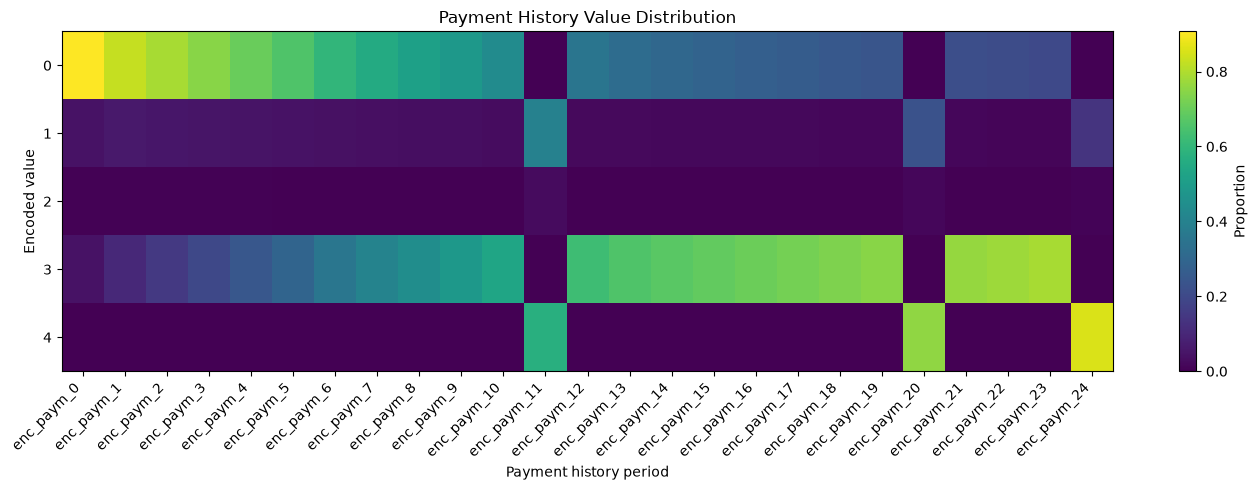

In [19]:
payment_distribution = (df[payment_cols].apply(lambda col: col.value_counts(normalize=True)).T.fillna(0))

fig, ax = plt.subplots(figsize=(14, 5))

im = ax.imshow(
    payment_distribution.values.T,
    aspect="auto"
)

ax.set_title("Payment History Value Distribution")
ax.set_xlabel("Payment history period")
ax.set_ylabel("Encoded value")

ax.set_xticks(range(len(payment_cols)))
ax.set_xticklabels(payment_cols, rotation=45, ha="right")

ax.set_yticks(range(payment_distribution.shape[1]))
ax.set_yticklabels(payment_distribution.columns)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Proportion")

plt.tight_layout()
plt.show()

### Key observation

The distribution of encoded payment history values changes substantially across the historical periods.

This suggests that the payment history contains a sequential structure and that the position of a payment record within the history carries information.

Therefore, preserving recency and changes in payment behavior may be useful during feature engineering.

## 8. Credit Categorical Features

The dataset contains several encoded categorical features describing credit characteristics.

We examine their value distributions to identify dominant categories and highly imbalanced variables.

In [20]:
categorical_cols = ["enc_loans_account_cur",
                    "enc_loans_credit_type",
                    "enc_loans_account_holder_type",
                    "enc_loans_credit_status"]

df[categorical_cols].nunique()

enc_loans_account_cur            4
enc_loans_credit_type            6
enc_loans_account_holder_type    7
enc_loans_credit_status          7
dtype: int64

In [21]:
categorical_distribution = pd.DataFrame({col: df[col].value_counts(normalize=True).sort_index()
                                         for col in categorical_cols}).T.fillna(0)

categorical_distribution

,0,1,2,3,4,5,6
enc_loans_account_cur,0.000545,0.996534,0.002910,0.000011,0.000000,0.000000,0.000000
enc_loans_credit_type,0.021853,0.085642,0.025487,0.281840,0.554094,0.031085,0.000000
enc_loans_account_holder_type,0.000006,0.989155,0.000131,0.006122,0.003847,0.000045,0.000694
enc_loans_credit_status,0.000104,0.001617,0.310610,0.681177,0.004001,0.002418,0.000072


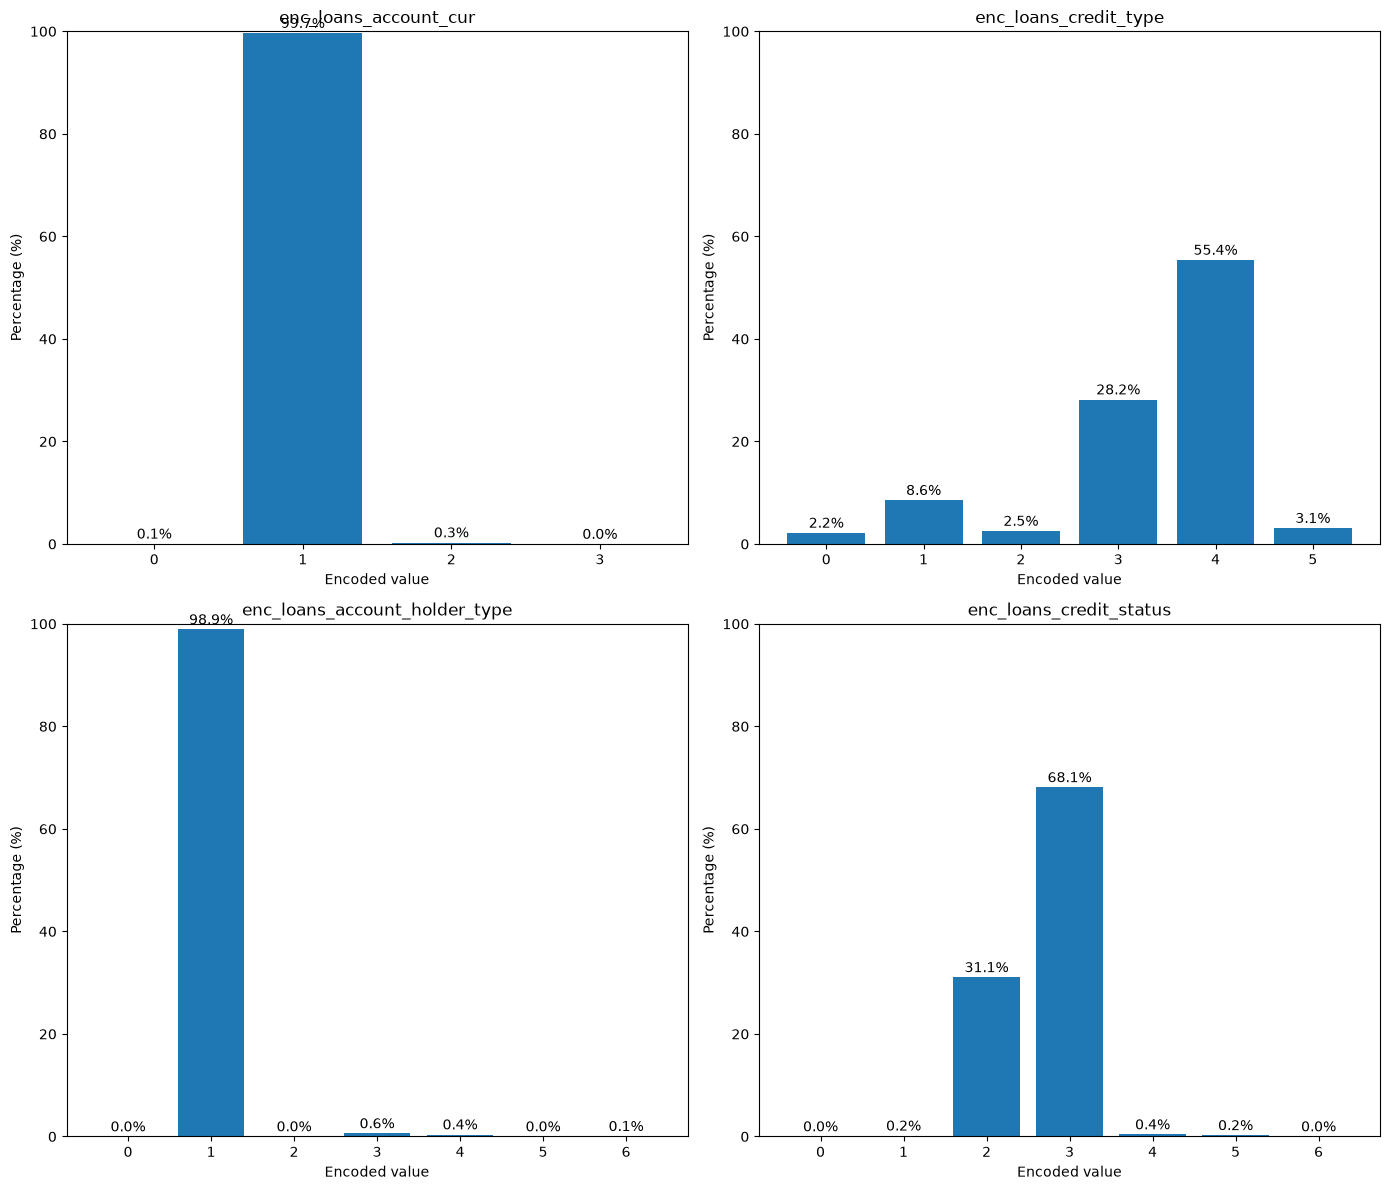

In [22]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(14, 12)
)

axes = axes.flatten()

for ax, col in zip(axes, categorical_cols):
    distribution = (
        df[col]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
    )

    ax.bar(
        distribution.index.astype(str),
        distribution.values
    )

    ax.set_title(col)
    ax.set_xlabel("Encoded value")
    ax.set_ylabel("Percentage (%)")
    ax.set_ylim(0, 100)

    for i, value in enumerate(distribution.values):
        ax.text(
            i,
            value + 1,
            f"{value:.1f}%",
            ha="center"
        )

plt.tight_layout()
plt.show()

### Key observations

The categorical features have highly uneven distributions.

- `enc_loans_account_cur` is dominated by a single category (99.65%).
- `enc_loans_account_holder_type` is also strongly concentrated in one category (98.92%).
- `enc_loans_credit_status` is mainly represented by two categories (68.12% and 31.06%).
- `enc_loans_credit_type` has a more diverse distribution, although two categories account for more than 80% of observations.

These distributions should be considered when designing the feature engineering and modeling pipeline.

## 9. Binarized Credit Characteristics

The `pre_*` features represent binarized characteristics of individual credit records.

The original numerical values were divided into non-overlapping intervals, and each interval was assigned an arbitrary numerical code. Therefore, the encoded values do not preserve the natural ordering or scale of the original variables.

For example, a higher encoded value of `pre_loans_credit_limit` does not necessarily represent a higher original credit limit.

We examine the frequency distributions of several credit characteristics to understand how observations are distributed across the encoded intervals.

In [23]:
financial_cols = ["pre_loans_credit_limit",
                  "pre_loans_outstanding",
                  "pre_loans_next_pay_summ"]

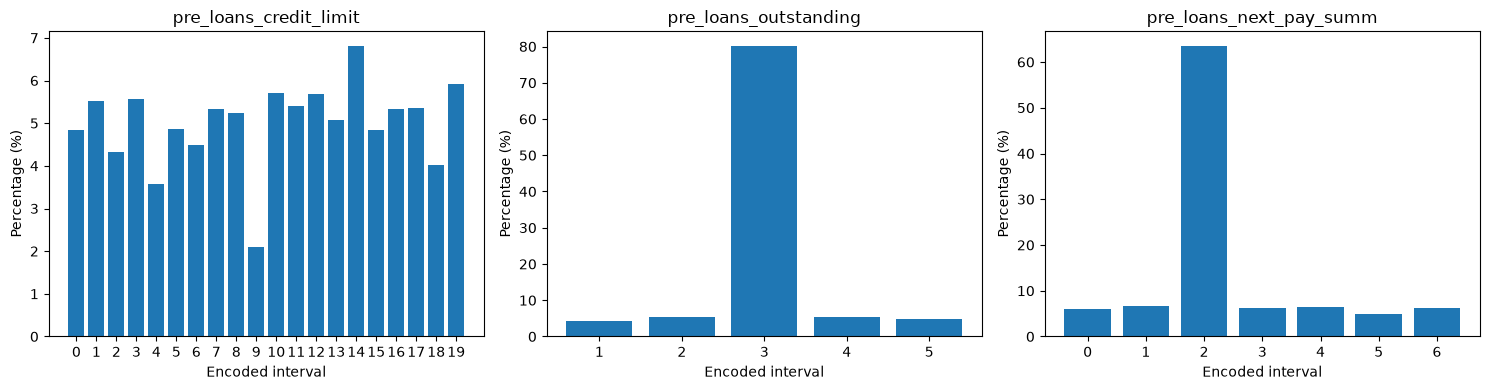

In [24]:
fig, axes = plt.subplots(nrows=1,
                         ncols=3,
                         figsize=(15, 4))

for ax, col in zip(axes, financial_cols):
    distribution = (df[col].value_counts(normalize=True).sort_index().mul(100))

    ax.bar(distribution.index.astype(str),
           distribution.values)

    ax.set_title(col)
    ax.set_xlabel("Encoded interval")
    ax.set_ylabel("Percentage (%)")

plt.tight_layout()
plt.show()

## 10. Delinquency History

The dataset contains several features describing delinquency events of different durations:

- up to 5 days;
- 5–30 days;
- 30–60 days;
- 60–90 days;
- more than 90 days.

The `pre_loans*` variables contain binarized numbers of delinquency events, while the corresponding `is_zero_loans*` features explicitly indicate whether a credit record has no delinquency events of a given duration.

In [25]:
delinquency_cols = ["pre_loans5",
                    "pre_loans530",
                    "pre_loans3060",
                    "pre_loans6090",
                    "pre_loans90"]

delinquency_cardinality = (df[delinquency_cols].nunique().sort_values())
delinquency_cardinality

pre_loans6090     3
pre_loans90       4
pre_loans3060     5
pre_loans5        8
pre_loans530     15
dtype: int64

### Absence of Delinquency Events

The binary `is_zero_*` features allow direct interpretation of whether a particular type of delinquency is absent from a credit record.

We compare the proportion of credit records without delinquency events across different delinquency durations.

In [26]:
zero_delinquency_cols = ["is_zero_loans5",
                         "is_zero_loans530",
                         "is_zero_loans3060",
                         "is_zero_loans6090",
                         "is_zero_loans90"]

no_delinquency_share = (df[zero_delinquency_cols].mean().mul(100))
no_delinquency_share

is_zero_loans5       90.491886
is_zero_loans530     83.169091
is_zero_loans3060    95.874158
is_zero_loans6090    97.861119
is_zero_loans90      97.930749
dtype: float64

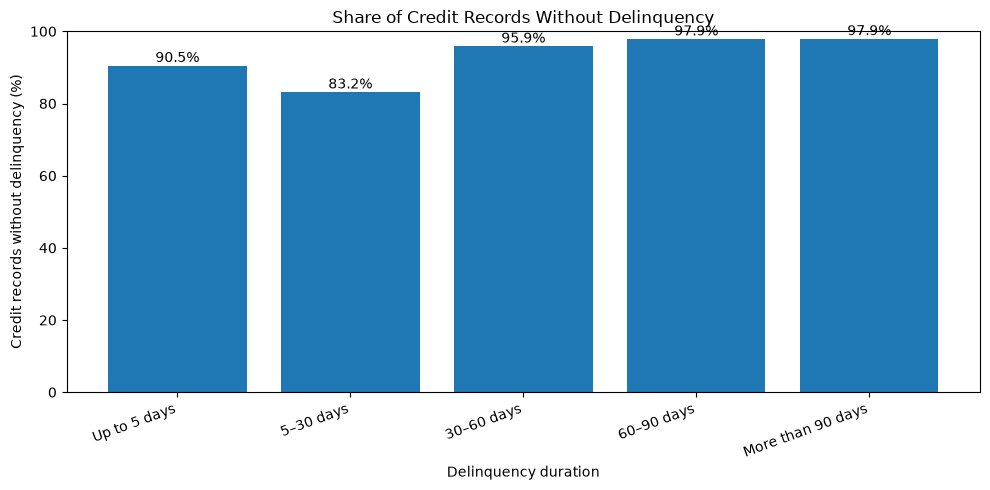

In [27]:
delinquency_labels = {"is_zero_loans5": "Up to 5 days",
                      "is_zero_loans530": "5–30 days",
                      "is_zero_loans3060": "30–60 days",
                      "is_zero_loans6090": "60–90 days",
                      "is_zero_loans90": "More than 90 days"}

plot_data = no_delinquency_share.rename(index=delinquency_labels)

plt.figure(figsize=(10, 5))

bars = plt.bar(plot_data.index,
               plot_data.values)

plt.ylabel("Credit records without delinquency (%)")
plt.xlabel("Delinquency duration")
plt.title("Share of Credit Records Without Delinquency")

plt.xticks(rotation=20, ha="right")
plt.ylim(0, 100)

for bar, value in zip(bars, plot_data.values):
    plt.text(bar.get_x() + bar.get_width() / 2,
             value + 1,
             f"{value:.1f}%",
             ha="center")

plt.tight_layout()
plt.show()

### Key observations

Most credit records have no delinquency events, especially for longer delinquency periods.

- 90.5% of credit records have no delinquency of up to 5 days.
- 83.2% have no delinquency between 5 and 30 days.
- 95.9% have no delinquency between 30 and 60 days.
- Approximately 97.9% have no delinquency longer than 60 days.

Longer delinquency events are therefore relatively rare in the credit history data. The binary delinquency indicators may provide useful information for distinguishing clients with different credit behavior.

### Delinquency at the Client Level

Since each client may have multiple credit records, record-level delinquency rates do not fully describe the client's credit history.

We therefore examine whether each client has experienced at least one delinquency event of each duration.

In [28]:
client_delinquency = (1 - df.groupby("id")[zero_delinquency_cols].min())

client_delinquency_share = (client_delinquency.mean().mul(100))

client_delinquency_share

is_zero_loans5       38.8104
is_zero_loans530     55.9388
is_zero_loans3060    19.8604
is_zero_loans6090    11.4780
is_zero_loans90      11.1152
dtype: float64

In [29]:
record_delinquency_share = 100 - no_delinquency_share

In [30]:
delinquency_comparison = pd.DataFrame({"Credit records": record_delinquency_share,
                                       "Clients": client_delinquency_share})

delinquency_comparison = delinquency_comparison.rename(index=delinquency_labels)
delinquency_comparison

,Credit records,Clients
Up to 5 days,9.508114,38.8104
5–30 days,16.830909,55.9388
30–60 days,4.125842,19.8604
60–90 days,2.138881,11.4780
More than 90 days,2.069251,11.1152


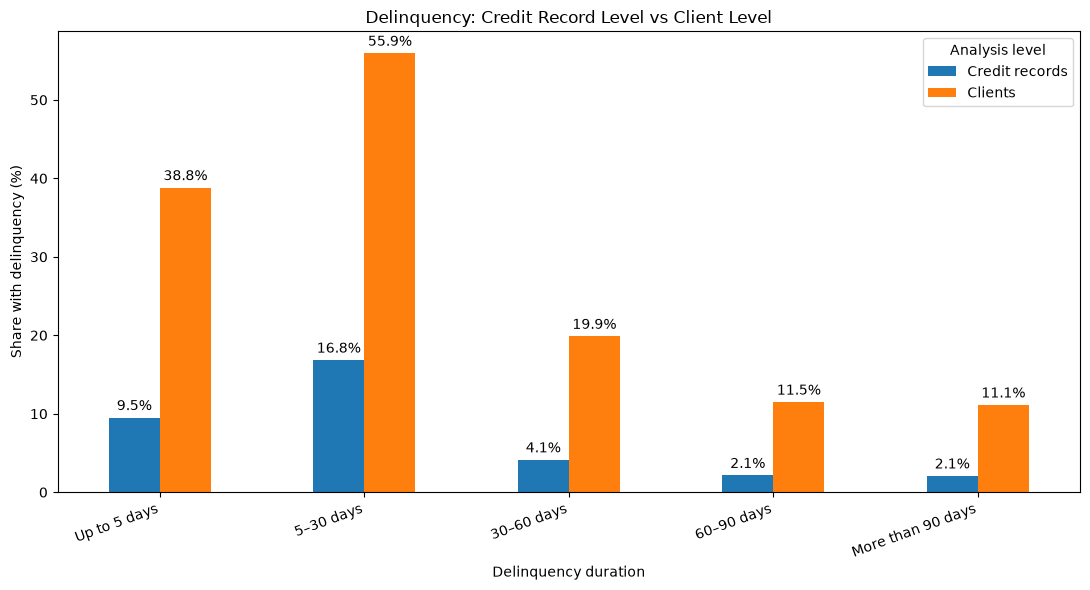

In [31]:
ax = delinquency_comparison.plot(kind="bar",
                                 figsize=(11, 6))

plt.ylabel("Share with delinquency (%)")
plt.xlabel("Delinquency duration")
plt.title("Delinquency: Credit Record Level vs Client Level")

plt.xticks(rotation=20, ha="right")
plt.legend(title="Analysis level")

for container in ax.containers:
    ax.bar_label(container,
                 fmt="%.1f%%",
                 padding=3)

plt.tight_layout()
plt.show()

### Key observations

Delinquency events are relatively uncommon at the individual credit-record level, particularly for longer delinquency periods. However, the picture changes substantially when the entire credit history of a client is considered.

For example, delinquency of more than 90 days appears in only about 2.1% of individual credit records, while 11.1% of clients have experienced at least one such event in their credit history.

Similarly, 5–30 day delinquency appears in 16.8% of credit records but has occurred at least once for 55.9% of clients.

This difference highlights the importance of aggregating credit-record information at the client level. Features describing whether a client has ever experienced delinquency, as well as its frequency and severity, may provide useful information for default prediction.

## 11. Default Risk Analysis

The prediction target is defined at the client level, while the raw credit history contains multiple credit records for each client.

To examine the relationship between credit history and default risk, we first aggregate selected interpretable characteristics to the client level and then compare default and non-default clients.

In [32]:
client_analysis = (credits_per_client.rename("credit_count").to_frame().merge(target[["id", "flag"]],
                                                                              left_index=True,
                                                                              right_on="id",
                                                                              how="left"))
client_analysis.groupby("flag")["credit_count"].agg(["count", "mean", "median"])

,count,mean,median
flag,,,
0,242266,7.915341,7.0
1,7734,7.383760,6.0


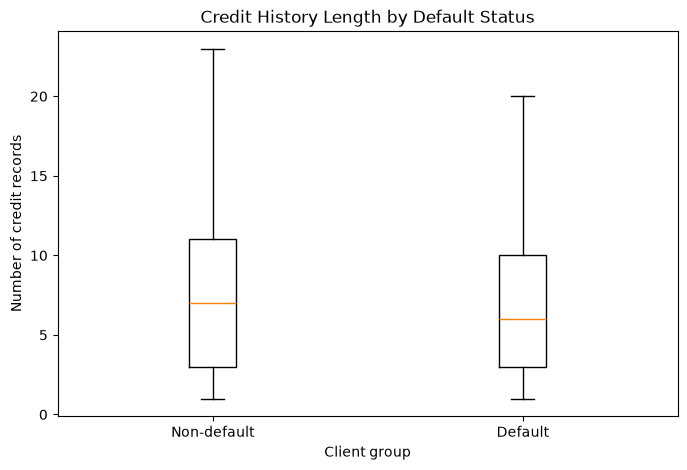

In [33]:
plt.figure(figsize=(8, 5))

plt.boxplot([client_analysis.loc[client_analysis["flag"] == 0, "credit_count"],
             client_analysis.loc[client_analysis["flag"] == 1, "credit_count"]],
            tick_labels=["Non-default", "Default"],
            showfliers=False
)

plt.ylabel("Number of credit records")
plt.xlabel("Client group")
plt.title("Credit History Length by Default Status")

plt.show()

### Key observation

The number of credit records is similar for default and non-default clients.

Non-default clients have an average of 7.92 credit records, compared with 7.38 for default clients. The median is 7 and 6 records, respectively.

This suggests that credit history length alone does not provide a clear separation between the two groups.

In [34]:
client_delinquency_target = (client_delinquency.merge(target[["id", "flag"]],
                                                      left_index=True,
                                                      right_on="id",
                                                      how="left"))

In [35]:
delinquency_by_target = (client_delinquency_target.groupby("flag")[zero_delinquency_cols].mean().mul(100).T)

delinquency_by_target.columns = ["Non-default",
                                 "Default"]

delinquency_by_target = delinquency_by_target.rename(index=delinquency_labels)
delinquency_by_target

,Non-default,Default
Up to 5 days,38.558031,46.715800
5–30 days,55.628937,65.645203
30–60 days,19.415436,33.798810
60–90 days,11.110102,23.002327
More than 90 days,10.784427,21.476597


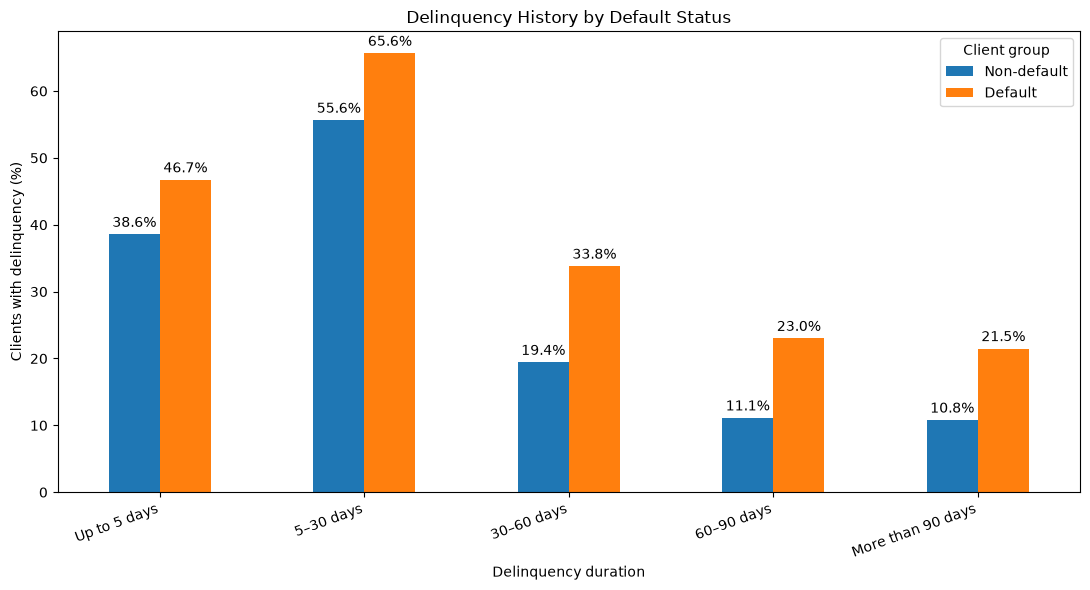

In [36]:
ax = delinquency_by_target.plot(kind="bar",
                                figsize=(11, 6))

plt.ylabel("Clients with delinquency (%)")
plt.xlabel("Delinquency duration")
plt.title("Delinquency History by Default Status")

plt.xticks(rotation=20, ha="right")
plt.legend(title="Client group")

for container in ax.containers:
    ax.bar_label(container,
                 fmt="%.1f%%",
                 padding=3)

plt.tight_layout()
plt.show()

### Key observations

Clients in the default group have a higher prevalence of delinquency events across all duration categories.

The difference becomes particularly pronounced for longer delinquency periods:

- 33.8% of default clients have experienced a 30–60 day delinquency, compared with 19.4% of non-default clients.
- 23.0% of default clients have experienced a 60–90 day delinquency, compared with 11.1% of non-default clients.
- 21.5% of default clients have experienced a delinquency longer than 90 days, compared with 10.8% of non-default clients.

This suggests that delinquency history, particularly longer delinquency periods, may contain useful predictive information for distinguishing higher-risk clients.

In [37]:
delinquency_prevalence_ratio = (delinquency_by_target["Default"] / delinquency_by_target["Non-default"])
delinquency_prevalence_ratio

Up to 5 days         1.211571
5–30 days            1.180055
30–60 days           1.740822
60–90 days           2.070397
More than 90 days    1.991445
dtype: float64

## 12. Key Findings and Next Steps

The exploratory analysis revealed several important characteristics of the dataset that will guide the subsequent feature engineering and modeling stages.

### Key Findings

1. **Multiple credit records per client**  
   The raw dataset is structured at the credit-product level, while the prediction target is defined at the client level. Clients have a median of 7 credit records, with histories ranging from 1 to 51 records.

2. **Strong class imbalance**  
   Only 3.55% of clients belong to the default class, compared with 96.45% non-default clients. This imbalance should be considered when evaluating model performance.

3. **No missing values**  
   No missing values were identified in the analyzed data partition, so missing-value imputation is not required at this stage.

4. **Predominantly low-cardinality features**  
   Most variables are binary, categorical, or binarized numerical characteristics. The numerical codes assigned to binarized features do not preserve the natural ordering of the original values and should therefore not be interpreted as continuous measurements.

5. **Chronological credit history**  
   The `rn` feature preserves the ordering of credit products within each client's history, with higher values corresponding to more recently opened credit products. This makes it possible to construct features describing changes in credit behavior over time.

6. **Structured payment history**  
   The `enc_paym_*` variables provide a sequence of encoded monthly payment statuses. Their distributions vary across historical periods, suggesting that both payment behavior and its position within the history may contain useful predictive information.

7. **Delinquency history differs between default and non-default clients**  
   Default clients show a higher prevalence of delinquency across all analyzed duration categories. The difference is particularly pronounced for longer delinquency periods. For example, 21.5% of default clients have experienced delinquency longer than 90 days, compared with 10.8% of non-default clients.

8. **Credit history length alone provides limited separation**  
   Default and non-default clients have similar numbers of credit records, suggesting that the number of credits alone is unlikely to provide strong separation between the two groups.

### Next Steps

The next stage will transform the credit-level dataset into a client-level feature matrix suitable for model training.

Feature engineering will focus on:

- aggregating credit characteristics at the client level;
- capturing the frequency and presence of delinquency events;
- extracting information from payment history;
- preserving information about the chronological order of credit records;
- handling categorical and binarized features appropriately;
- preparing the final feature matrix for model training and validation.